In [5]:
import os
import pandas as pd
import numpy as np

# Automatically find the data path
def find_data_path():
    """Try multiple possible paths to find the data"""
    possible_paths = [
        "../data/raw/",           # When running from notebooks/
        "data/raw/",               # When running from project root
        "./data/raw/",             # Alternative
        "../ml-internship-project/data/raw/",  # One level up with folder
        "C:/Users/naresh/ml-internship-project/data/raw/",  # Full path
    ]
    
    for path in possible_paths:
        test_file = os.path.join(path, "u.data")
        if os.path.exists(test_file):
            print(f"✅ Found data at: {path}")
            return path
    
    print("❌ Could not find data in any path")
    print("Current directory:", os.getcwd())
    print("Files in current directory:", os.listdir())
    return None

DATA_PATH = find_data_path()

# If found, load the data
if DATA_PATH:
    # Load ratings
    ratings = pd.read_csv(f"{DATA_PATH}u.data", sep='\t', 
                          names=['user_id', 'item_id', 'rating', 'timestamp'])
    
    # Load movies
    movies = pd.read_csv(f"{DATA_PATH}u.item", sep='|', encoding='latin-1',
                         names=['item_id', 'title', 'release_date', 'video_release_date',
                                'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation',
                                'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                                'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                                'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])
    
    # Load users
    users = pd.read_csv(f"{DATA_PATH}u.user", sep='|',
                        names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])
    
    print("\n✅ Data loaded successfully!")
    print(f"Ratings: {ratings.shape}")
    print(f"Movies: {movies.shape}")
    print(f"Users: {users.shape}")
else:
    print("❌ Please fix the path manually")

✅ Found data at: ../data/raw/

✅ Data loaded successfully!
Ratings: (100000, 4)
Movies: (1682, 24)
Users: (943, 5)


In [6]:
# =============================================
# DATA INSPECTION & UNDERSTANDING
# =============================================

print("\n" + "="*60)
print("RATINGS DATA")
print("="*60)
print("Shape:", ratings.shape)
print("\nFirst 5 rows:")
print(ratings.head())
print("\nData Types:")
print(ratings.dtypes)
print("\nMissing Values:")
print(ratings.isnull().sum())
print("\nBasic Statistics:")
print(ratings.describe())

print("\n" + "="*60)
print("MOVIES DATA")
print("="*60)
print("Shape:", movies.shape)
print("\nFirst 5 rows:")
print(movies.head())
print("\nMissing Values:")
print(movies.isnull().sum())

print("\n" + "="*60)
print("USERS DATA")
print("="*60)
print("Shape:", users.shape)
print("\nFirst 5 rows:")
print(users.head())
print("\nMissing Values:")
print(users.isnull().sum())
print("\nUser Demographics:")
print("Age range:", users['age'].min(), "-", users['age'].max())
print("Gender distribution:\n", users['gender'].value_counts())
print("Occupation distribution:\n", users['occupation'].value_counts())


RATINGS DATA
Shape: (100000, 4)

First 5 rows:
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Data Types:
user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

Missing Values:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Basic Statistics:
            user_id        item_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.88260

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries imported successfully!")

# =============================================
# LOAD DATA
# =============================================

# Load ratings
ratings = pd.read_csv('../data/raw/u.data', sep='\t', 
                      names=['user_id', 'item_id', 'rating', 'timestamp'])

# Load movies
movies = pd.read_csv('../data/raw/u.item', sep='|', encoding='latin-1',
                     names=['item_id', 'title', 'release_date', 'video_release_date',
                            'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                            'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                            'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])

# Load users
users = pd.read_csv('../data/raw/u.user', sep='|',
                    names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

print("✅ Data loaded successfully!")
print(f"Ratings: {ratings.shape}")
print(f"Movies: {movies.shape}")
print(f"Users: {users.shape}")

# =============================================
# DATA CLEANING
# =============================================

print("\nStarting data cleaning...")

# 1. Handle duplicates
ratings = ratings.drop_duplicates(subset=['user_id', 'item_id'])
print(f"Ratings after removing duplicates: {ratings.shape}")

# 2. Handle rating outliers (clip to 1-5 range)
ratings['rating'] = ratings['rating'].clip(1, 5)
print("Ratings clipped to 1-5 range")

# 3. Clean movies
movies = movies.drop(['video_release_date', 'IMDb_URL'], axis=1)
movies['release_date'] = movies['release_date'].fillna('Unknown')
movies['release_date'] = movies['release_date'].replace('', 'Unknown')
print(f"Movies after cleaning: {movies.shape}")

# 4. Clean users (cap age at reasonable bounds)
users['age'] = users['age'].clip(18, 90)
print(f"Users age capped at 18-90 range")

print("\n✅ Data cleaning complete!")

✅ Libraries imported successfully!
✅ Data loaded successfully!
Ratings: (100000, 4)
Movies: (1682, 24)
Users: (943, 5)

Starting data cleaning...
Ratings after removing duplicates: (100000, 4)
Ratings clipped to 1-5 range
Movies after cleaning: (1682, 22)
Users age capped at 18-90 range

✅ Data cleaning complete!


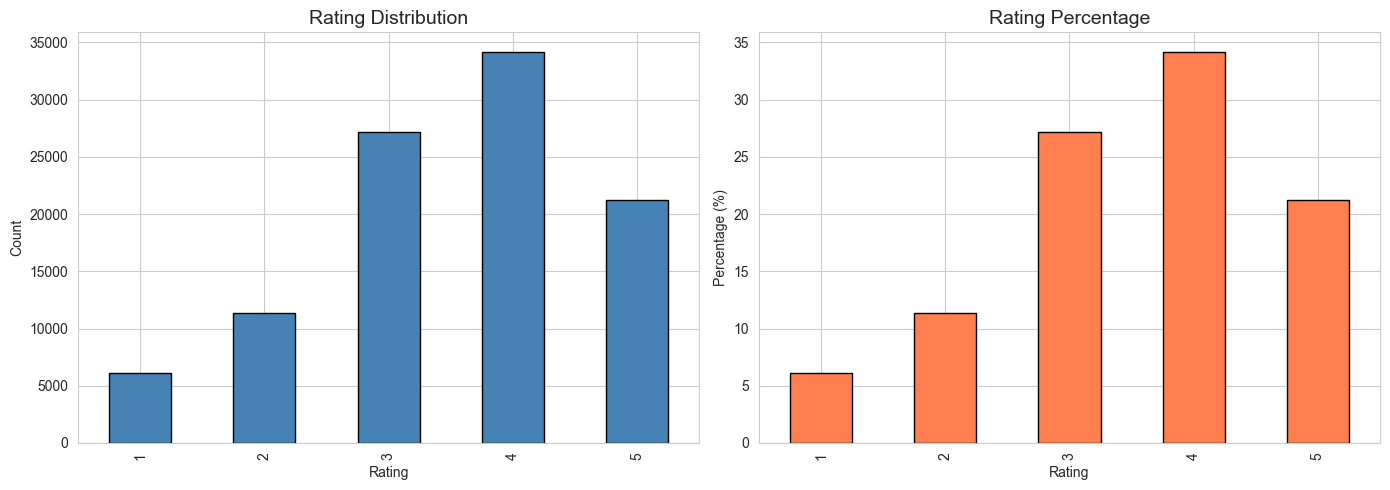

In [4]:
# =============================================
# EDA: RATING DISTRIBUTION
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating count
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], 
                                                    edgecolor='black', color='steelblue')
axes[0].set_title('Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Rating percentage
rating_pct = ratings['rating'].value_counts(normalize=True).sort_index() * 100
rating_pct.plot(kind='bar', ax=axes[1], edgecolor='black', color='coral')
axes[1].set_title('Rating Percentage', fontsize=14)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

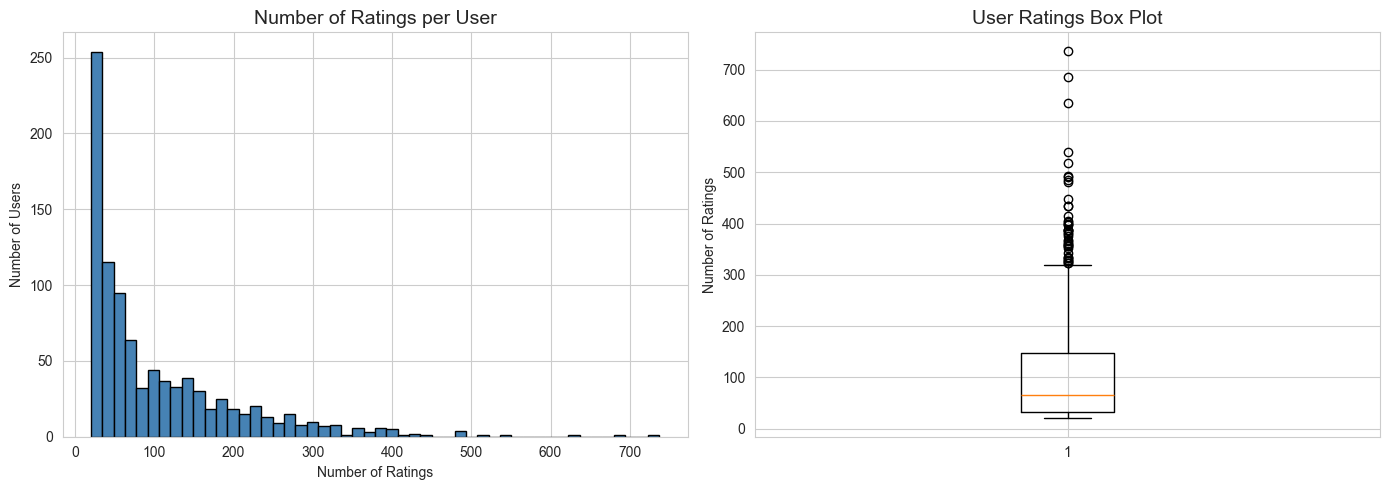

Average ratings per user: 106.04
Median ratings per user: 65
Max ratings by one user: 737
Min ratings by one user: 20


In [5]:
# =============================================
# EDA: USER ACTIVITY
# =============================================

user_ratings = ratings.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
user_ratings.hist(bins=50, ax=axes[0], edgecolor='black', color='steelblue')
axes[0].set_title('Number of Ratings per User', fontsize=14)
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')

# Box plot
axes[1].boxplot(user_ratings)
axes[1].set_title('User Ratings Box Plot', fontsize=14)
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

print(f"Average ratings per user: {user_ratings.mean():.2f}")
print(f"Median ratings per user: {user_ratings.median():.0f}")
print(f"Max ratings by one user: {user_ratings.max()}")
print(f"Min ratings by one user: {user_ratings.min()}")

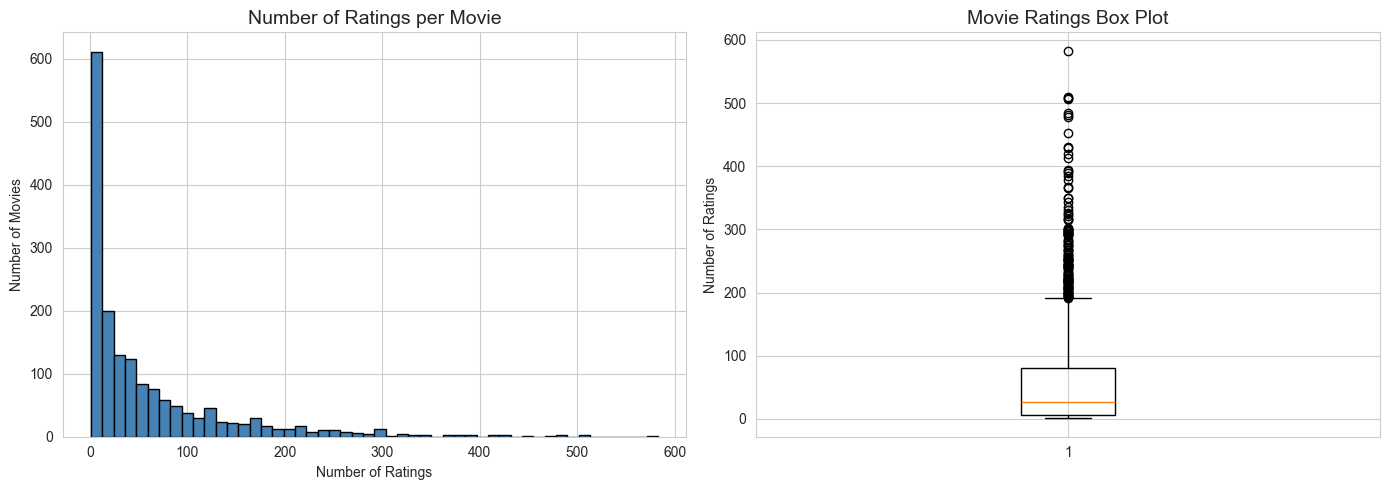

Average ratings per movie: 59.45
Median ratings per movie: 27
Max ratings for one movie: 583
Min ratings for one movie: 1


In [7]:
# =============================================
# EDA: MOVIE ACTIVITY
# =============================================

movie_ratings = ratings.groupby('item_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
movie_ratings.hist(bins=50, ax=axes[0], edgecolor='black', color='steelblue')
axes[0].set_title('Number of Ratings per Movie', fontsize=14)
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')

# Box plot
axes[1].boxplot(movie_ratings)
axes[1].set_title('Movie Ratings Box Plot', fontsize=14)
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

print(f"Average ratings per movie: {movie_ratings.mean():.2f}")
print(f"Median ratings per movie: {movie_ratings.median():.0f}")
print(f"Max ratings for one movie: {movie_ratings.max()}")
print(f"Min ratings for one movie: {movie_ratings.min()}")

In [8]:
# =============================================
# EDA: DATA SPARSITY
# =============================================

n_users = ratings['user_id'].nunique()
n_items = ratings['item_id'].nunique()
n_ratings = len(ratings)

total_possible = n_users * n_items
sparsity = 1 - (n_ratings / total_possible)

print("="*60)
print("DATA SPARSITY ANALYSIS")
print("="*60)
print(f"Number of users: {n_users:,}")
print(f"Number of items: {n_items:,}")
print(f"Number of ratings: {n_ratings:,}")
print(f"Total possible ratings: {total_possible:,}")
print(f"Sparsity: {sparsity:.2%}")
print(f"Data density: {(1-sparsity):.2%}")

DATA SPARSITY ANALYSIS
Number of users: 943
Number of items: 1,682
Number of ratings: 100,000
Total possible ratings: 1,586,126
Sparsity: 93.70%
Data density: 6.30%


In [9]:
# =============================================
# FEATURE ENGINEERING: USER FEATURES
# =============================================

user_features = ratings.groupby('user_id').agg({
    'rating': ['mean', 'std', 'count']
}).reset_index()

user_features.columns = ['user_id', 'user_avg_rating', 
                         'user_rating_std', 'user_rating_count']

# Fill NaN (users with only one rating)
user_features['user_rating_std'] = user_features['user_rating_std'].fillna(0)

print("User features created:")
print(user_features.head())
print(f"\nUser features shape: {user_features.shape}")

User features created:
   user_id  user_avg_rating  user_rating_std  user_rating_count
0        1         3.610294         1.263585                272
1        2         3.709677         1.030472                 62
2        3         2.796296         1.219026                 54
3        4         4.333333         0.916831                 24
4        5         2.874286         1.362963                175

User features shape: (943, 4)


In [10]:
# =============================================
# FEATURE ENGINEERING: MOVIE FEATURES
# =============================================

movie_features = ratings.groupby('item_id').agg({
    'rating': ['mean', 'std', 'count']
}).reset_index()

movie_features.columns = ['item_id', 'movie_avg_rating', 
                          'movie_rating_std', 'movie_rating_count']

# Fill NaN (movies with only one rating)
movie_features['movie_rating_std'] = movie_features['movie_rating_std'].fillna(0)

print("Movie features created:")
print(movie_features.head())
print(f"\nMovie features shape: {movie_features.shape}")

Movie features created:
   item_id  movie_avg_rating  movie_rating_std  movie_rating_count
0        1          3.878319          0.927897                 452
1        2          3.206107          0.966497                 131
2        3          3.033333          1.212760                  90
3        4          3.550239          0.965069                 209
4        5          3.302326          0.946446                  86

Movie features shape: (1682, 4)


In [11]:
# =============================================
# FEATURE ENGINEERING: TEMPORAL FEATURES
# =============================================

# Convert timestamp to datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Extract features
ratings['day_of_week'] = ratings['datetime'].dt.dayofweek
ratings['hour_of_day'] = ratings['datetime'].dt.hour
ratings['month_of_year'] = ratings['datetime'].dt.month
ratings['is_weekend'] = ratings['day_of_week'].isin([5, 6]).astype(int)

print("Temporal features added:")
print(ratings[['timestamp', 'datetime', 'day_of_week', 'hour_of_day', 'month_of_year', 'is_weekend']].head())

Temporal features added:
   timestamp            datetime  day_of_week  hour_of_day  month_of_year  \
0  881250949 1997-12-04 15:55:49            3           15             12   
1  891717742 1998-04-04 19:22:22            5           19              4   
2  878887116 1997-11-07 07:18:36            4            7             11   
3  880606923 1997-11-27 05:02:03            3            5             11   
4  886397596 1998-02-02 05:33:16            0            5              2   

   is_weekend  
0           0  
1           1  
2           0  
3           0  
4           0  


In [12]:
# =============================================
# MERGE ALL FEATURES INTO MASTER DATASET
# =============================================

# Start with ratings (which now has temporal features)
master = ratings.copy()

# Merge user features
master = master.merge(user_features, on='user_id', how='left')

# Merge movie features
master = master.merge(movie_features, on='item_id', how='left')

# Merge user demographics
master = master.merge(users[['user_id', 'age', 'gender', 'occupation']], 
                     on='user_id', how='left')

# Merge movie genres
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
              'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
              'Thriller', 'War', 'Western']

master = master.merge(movies[['item_id'] + genre_cols], 
                     on='item_id', how='left')

print("Master dataset created!")
print(f"Shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")

Master dataset created!
Shape: (100000, 36)
Columns: ['user_id', 'item_id', 'rating', 'timestamp', 'datetime', 'day_of_week', 'hour_of_day', 'month_of_year', 'is_weekend', 'user_avg_rating', 'user_rating_std', 'user_rating_count', 'movie_avg_rating', 'movie_rating_std', 'movie_rating_count', 'age', 'gender', 'occupation', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [13]:
# =============================================
# SAVE PROCESSED DATA
# =============================================

# First, create the processed folder if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Drop unnecessary columns for saving
master_save = master.drop(['timestamp', 'datetime'], axis=1)

# Save to CSV
master_save.to_csv('../data/processed/master_dataset.csv', index=False)

# Also save separate files
ratings.to_csv('../data/processed/ratings_clean.csv', index=False)
user_features.to_csv('../data/processed/user_features.csv', index=False)
movie_features.to_csv('../data/processed/movie_features.csv', index=False)

print("✅ All processed data saved successfully!")
print(f"Master dataset saved to: data/processed/master_dataset.csv")
print(f"Shape: {master_save.shape}")
print(f"Columns: {master_save.columns.tolist()}")

✅ All processed data saved successfully!
Master dataset saved to: data/processed/master_dataset.csv
Shape: (100000, 34)
Columns: ['user_id', 'item_id', 'rating', 'day_of_week', 'hour_of_day', 'month_of_year', 'is_weekend', 'user_avg_rating', 'user_rating_std', 'user_rating_count', 'movie_avg_rating', 'movie_rating_std', 'movie_rating_count', 'age', 'gender', 'occupation', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
